<a href="https://colab.research.google.com/github/Ahmad-Zainudin-Fanani/PembelajaranMesin2026/blob/main/TG4_244107020051_AhmadZainudinFanani.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praktikum 1

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Iris.csv to Iris.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df = pd.read_csv('Iris.csv')

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
# Seleksi Fitur

X = df.iloc[:, 1:-1]
y = df.iloc[:, -1]

X.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


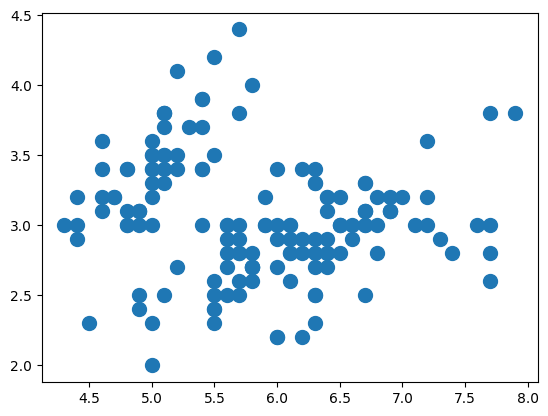

In [ ]:
# Plot Data
# Karena data 4 dimensi, maka akan kita coba
# plot cluster berdasarkan Sepal Length dan Sepal Width  saja

plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100)

In [ ]:
# Buat Model KMeans
# Kali ini kita coba menggunakan k=2 - anggap saja kita tidak tahu jumlah label ada 3 :)

from sklearn.cluster import KMeans

# Inisiasi obyek KMeans
cl_kmeans = KMeans(n_clusters=2)

# Fit dan predict model
y_kmeans = cl_kmeans.fit_predict(X)

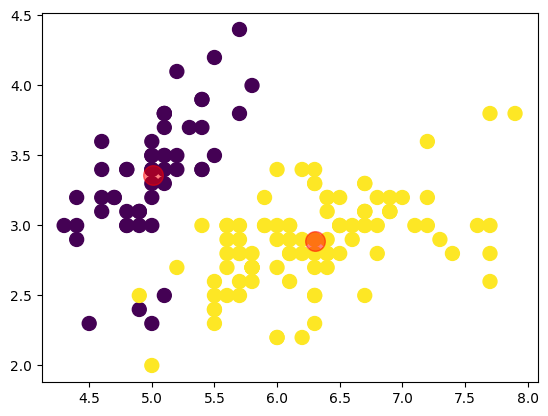

In [ ]:
# Plot hasi cluster berdasarkan Sepal Length dan Sepal Width
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100, c=y_kmeans)

# Plot centroid
centers = cl_kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.5)

In [ ]:
# Cek Nilai SSE
print(f'Nilai SSE: {cl_kmeans.inertia_}')

Nilai SSE: 152.36870647733915


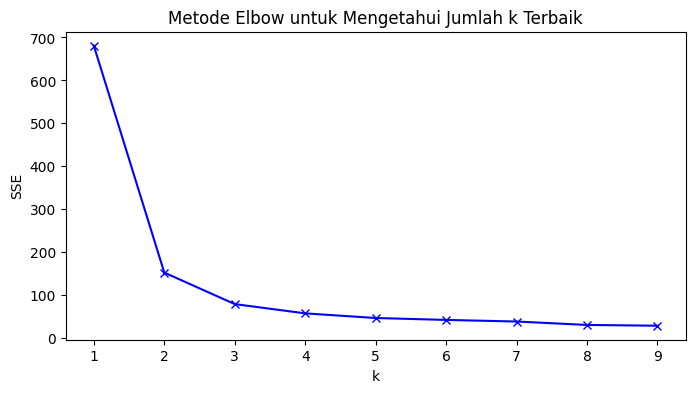

In [ ]:
# Implementasi Metode Elbow

# List nilai SSE
sse = []

# Cari k terbaik dari 1-10
K = range(1,10)

# Cek nilai SSE setiap k
for k in K:
 kmeanModel = KMeans(n_clusters=k)
 kmeanModel.fit(X)
 sse.append(kmeanModel.inertia_)


# Plotting the distortions
plt.figure(figsize=(8,4))
plt.plot(K, sse, "bx-")
plt.xlabel("k")
plt.ylabel("SSE")
plt.title("Metode Elbow untuk Mengetahui Jumlah k Terbaik")
plt.show()

In [ ]:
# Cek Nilai SSE setiap k
for idx, sse_val in enumerate(sse, start=1):
    print(f'k={idx}; SSE={sse_val}')

k=1; SSE=680.8243999999996
k=2; SSE=152.36870647733915
k=3; SSE=78.94506582597728
k=4; SSE=57.34540931571815
k=5; SSE=46.535582051282034
k=6; SSE=42.07002801932368
k=7; SSE=38.34481550802139
k=8; SSE=30.37497544122546
k=9; SSE=28.557732041780017


# Praktikum 2

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import numpy as np

### Pengantar k-Means

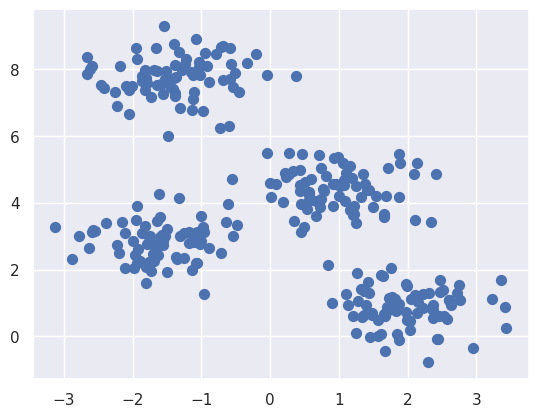

In [ ]:
from sklearn.datasets import make_blobs
X, y_true = make_blobs(n_samples=300, centers=4,
                       cluster_std=0.60, random_state=0)
plt.scatter(X[:, 0], X[:, 1], s=50);

In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

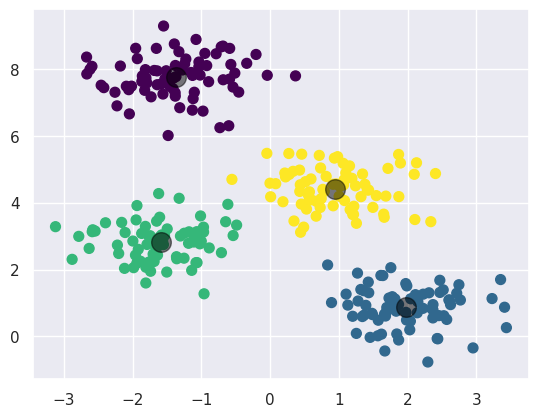

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)

### Algoritma Expectation-Maximization

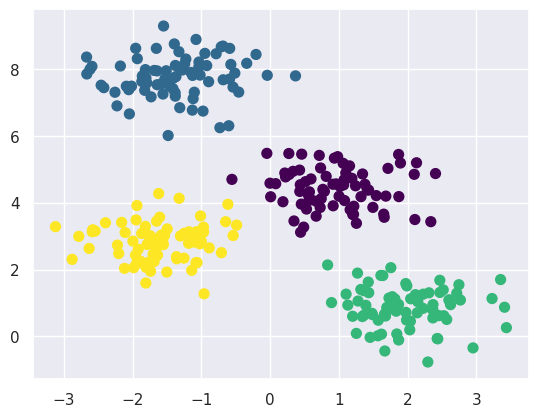

In [ ]:
from sklearn.metrics import pairwise_distances_argmin

def find_clusters(X, n_clusters, rseed=2):
    # 1. Randomly choose clusters
    rng = np.random.RandomState(rseed)
    i = rng.permutation(X.shape[0])[:n_clusters]
    centers = X[i]

    while True:
        # 2a. input label center yang baru
        labels = pairwise_distances_argmin(X, centers)

        # 2b. update center dari titik baru
        new_centers = np.array([X[labels == i].mean(0)
                                for i in range(n_clusters)])

        # 2c. cek konvergensi
        if np.all(centers == new_centers):
            break
        centers = new_centers

    return centers, labels

centers, labels = find_clusters(X, 4)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

### Perubahan random

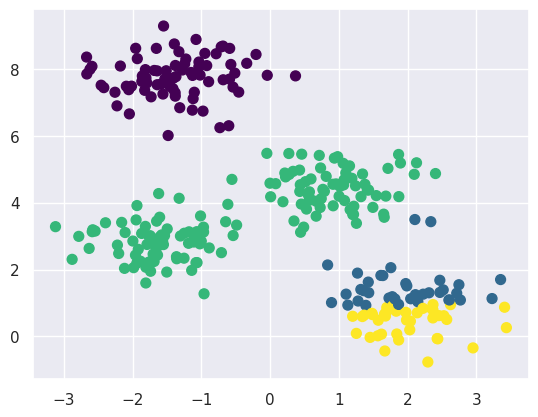

In [ ]:
centers, labels = find_clusters(X, 4, rseed=0)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

### Optimalisasi Jumlah Klaster

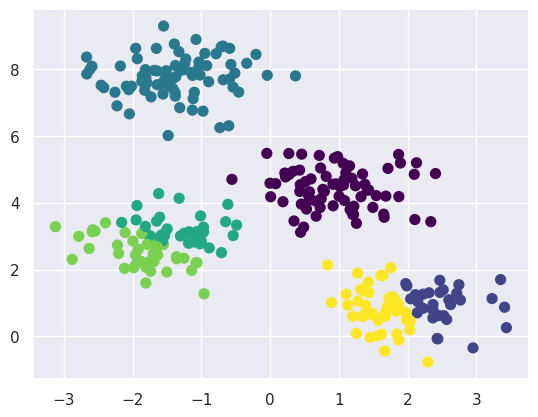

In [ ]:
labels = KMeans(6, random_state=0).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis');

### Batas Klaster yang Tidak Selalu Linier

In [ ]:
from sklearn.datasets import make_moons
X, y = make_moons(200, noise=.05, random_state=0)

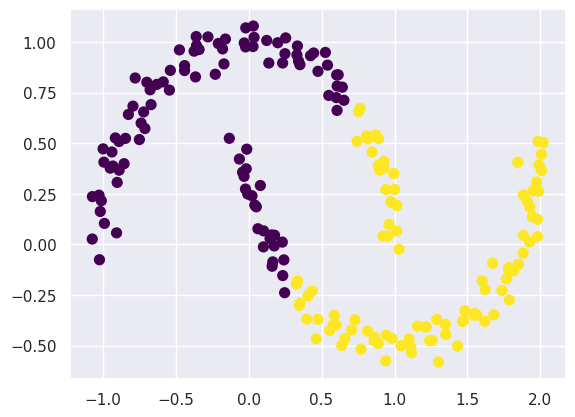

In [ ]:
labels = KMeans(2, random_state=0).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


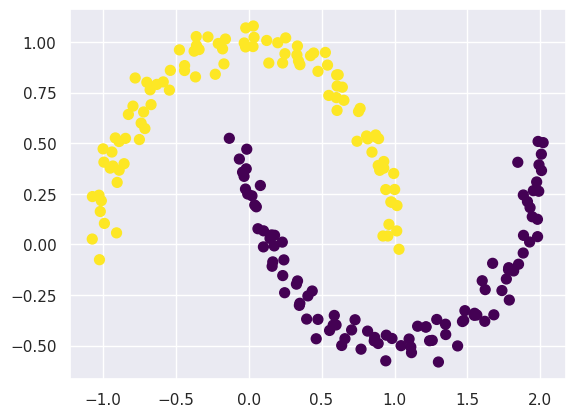

In [ ]:
from sklearn.cluster import SpectralClustering
model = SpectralClustering(n_clusters=2, affinity='nearest_neighbors',
                           assign_labels='kmeans')
labels = model.fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis');

### Contoh Kasus 1: Karakter Angka

In [ ]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.data.shape

(1797, 64)

In [ ]:
# terapkan K-Means
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(digits.data)
kmeans.cluster_centers_.shape

(10, 64)

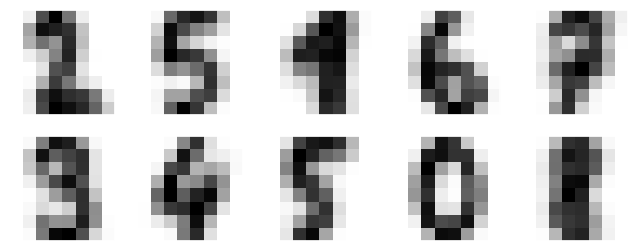

In [ ]:
fig, ax = plt.subplots(2, 5, figsize=(8, 3))
centers = kmeans.cluster_centers_.reshape(10, 8, 8)
for axi, center in zip(ax.flat, centers):
    axi.set(xticks=[], yticks=[])
    axi.imshow(center, interpolation='nearest', cmap=plt.cm.binary)

In [ ]:
from scipy.stats import mode

labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(digits.target, labels)

0.7440178074568725

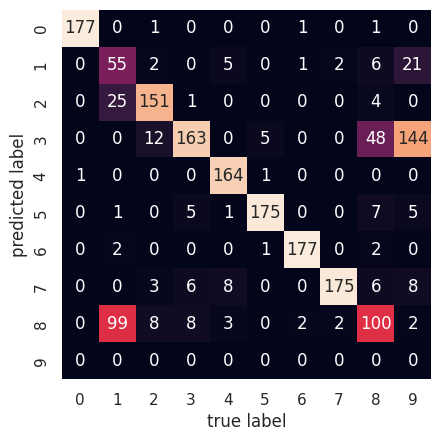

In [ ]:
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(digits.target, labels)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=digits.target_names,
            yticklabels=digits.target_names)
plt.xlabel('true label')
plt.ylabel('predicted label');

In [ ]:
from sklearn.manifold import TSNE


tsne = TSNE(n_components=2, init='random', random_state=0)
digits_proj = tsne.fit_transform(digits.data)

# hitung klaster
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(digits_proj)

# permutasi label
labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

# hitung akurasi
accuracy_score(digits.target, labels)

0.9410127991096272

### Studi Kasus 2: Kompresi Citra

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving flower.jpg to flower.jpg


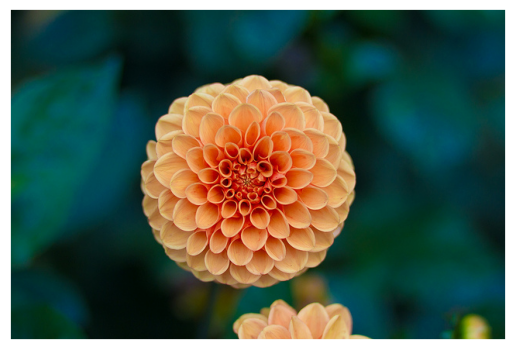

In [ ]:
from sklearn.datasets import load_sample_image
flower = load_sample_image("flower.jpg")
ax = plt.axes(xticks=[], yticks=[])
ax.imshow(flower);

In [ ]:
flower.shape

(427, 640, 3)

In [ ]:
data = flower / 255.0
data = data.reshape(427 * 640, 3)
data.shape

(273280, 3)

In [ ]:
def plot_pixels(data, title, colors=None, N=10000):
    if colors is None:
        colors = data

    # choose a random subset
    rng = np.random.RandomState(0)
    i = rng.permutation(data.shape[0])[:N]
    colors = colors[i]
    R, G, B = data[i].T

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    ax[0].scatter(R, G, color=colors, marker='.')
    ax[0].set(xlabel='Red', ylabel='Green', xlim=(0, 1), ylim=(0, 1))

    ax[1].scatter(R, B, color=colors, marker='.')
    ax[1].set(xlabel='Red', ylabel='Blue', xlim=(0, 1), ylim=(0, 1))

    fig.suptitle(title, size=20);

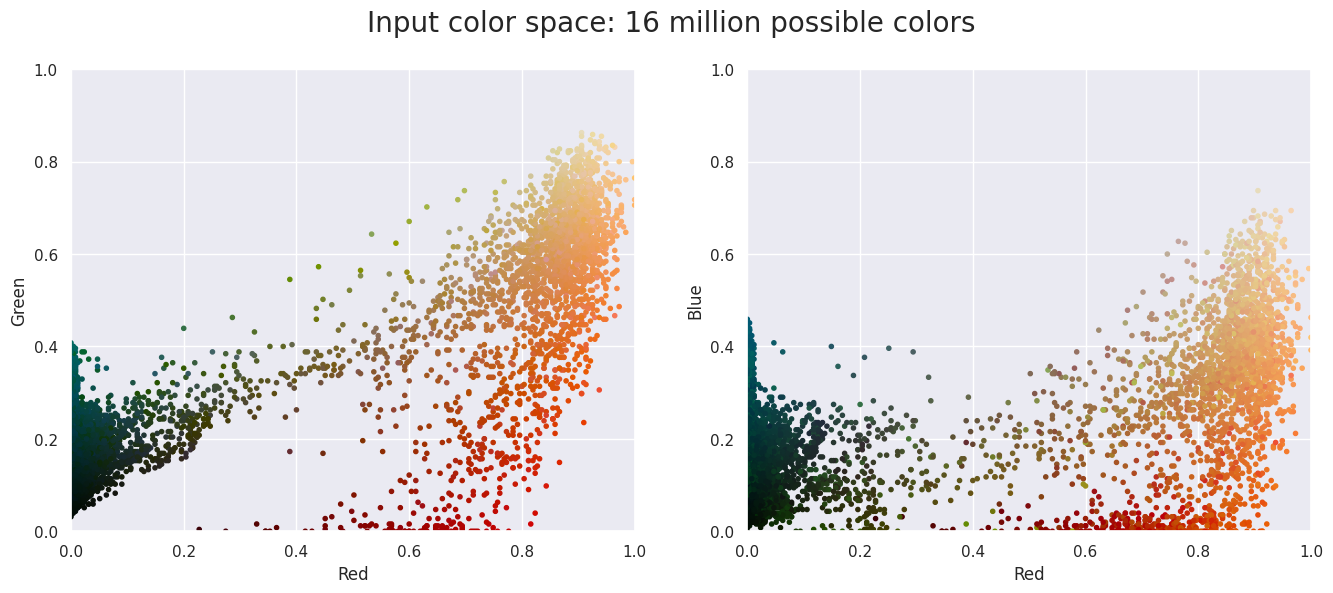

In [ ]:
plot_pixels(data, title='Input color space: 16 million possible colors')

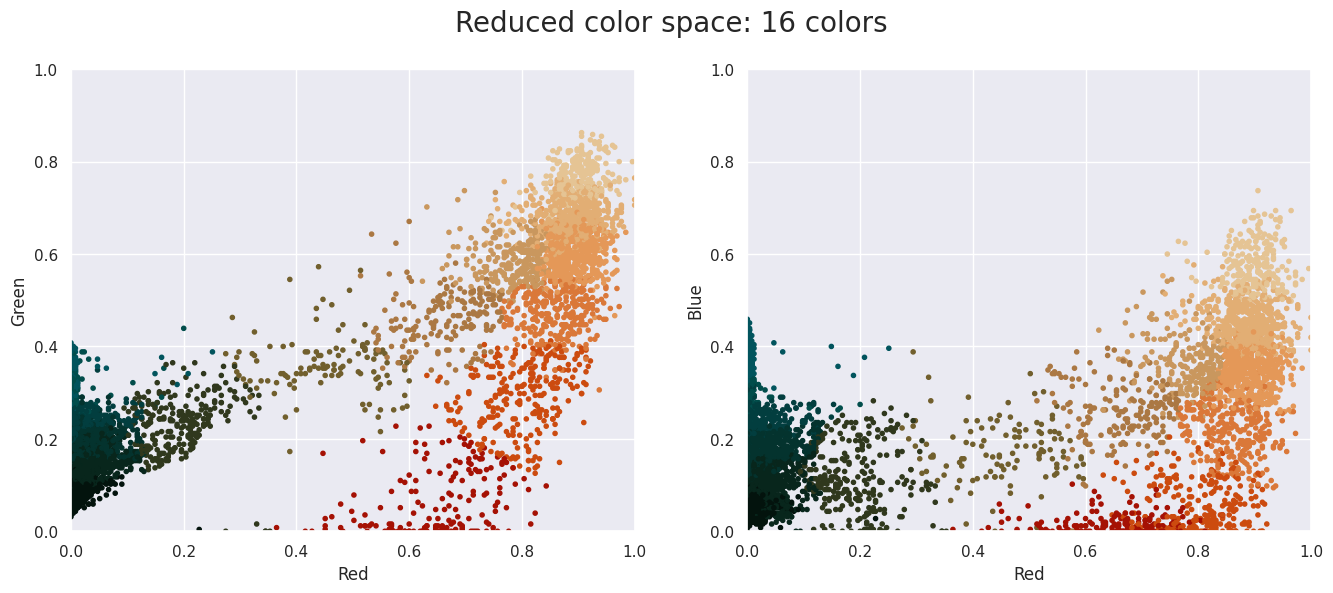

In [ ]:
import warnings; warnings.simplefilter('ignore')  # Fix NumPy issues.

from sklearn.cluster import MiniBatchKMeans
kmeans = MiniBatchKMeans(16)
kmeans.fit(data)
new_colors = kmeans.cluster_centers_[kmeans.predict(data)]

plot_pixels(data, colors=new_colors,title="Reduced color space: 16 colors")

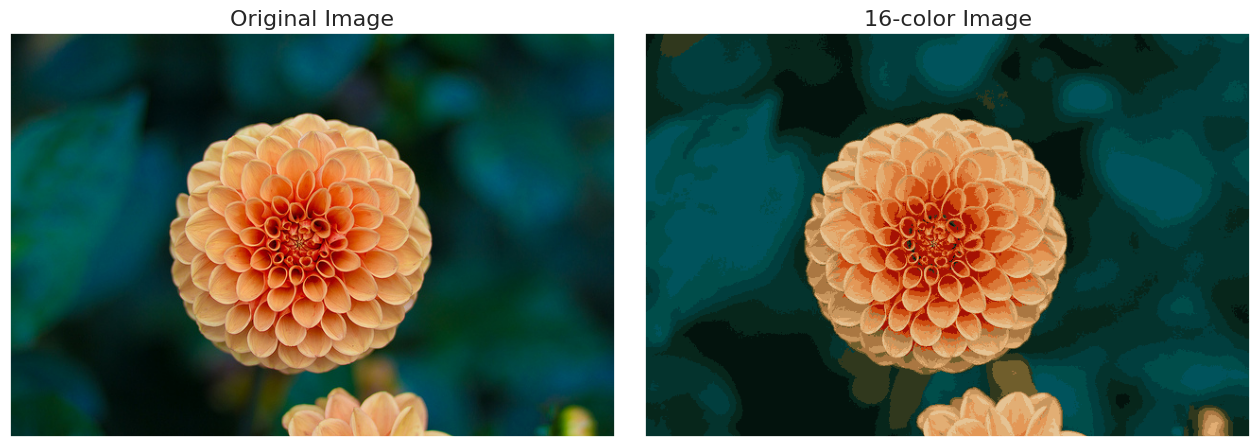

In [ ]:
flower_recolored = new_colors.reshape(flower.shape)

fig, ax = plt.subplots(1, 2, figsize=(16, 6),
                       subplot_kw=dict(xticks=[], yticks=[]))
fig.subplots_adjust(wspace=0.05)
ax[0].imshow(flower)
ax[0].set_title('Original Image', size=16)
ax[1].imshow(flower_recolored)
ax[1].set_title('16-color Image', size=16);

In [ ]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

# Menentukan titik pusat klaster
centers = [[1, 1], [-1, -1], [1, -1]]

# Generate dataset buatan
X, labels_true = make_blobs(
    n_samples=750, centers=centers, cluster_std=0.4, random_state=0
)

# Standarisasi fitur data
X = StandardScaler().fit_transform(X)

### Visualisasikan data yang dihasilkan dengan cara ini:

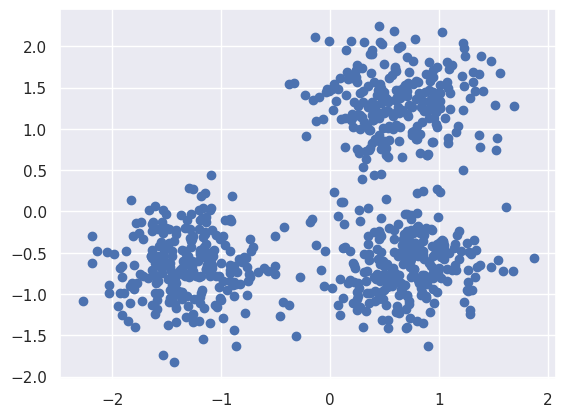

In [ ]:
import matplotlib.pyplot as plt

# Plot data menggunakan scatter plot
plt.scatter(X[:, 0], X[:, 1])
plt.show()

### Compute DBSCAN

In [ ]:
import numpy as np

from sklearn import metrics
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.3, min_samples=10).fit(X)
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 3
Estimated number of noise points: 18


### Evaluasi Kualitas Klasterisasi

In [ ]:
print(f"Homogeneity: {metrics.homogeneity_score(labels_true, labels):.3f}")
print(f"Completeness: {metrics.completeness_score(labels_true, labels):.3f}")
print(f"V-measure: {metrics.v_measure_score(labels_true, labels):.3f}")
print(f"Adjusted Rand Index: {metrics.adjusted_rand_score(labels_true, labels):.3f}")
print(
    "Adjusted Mutual Information: "
    f"{metrics.adjusted_mutual_info_score(labels_true, labels):.3f}"
)
print(f"Silhouette Coefficient: {metrics.silhouette_score(X, labels):.3f}")

Homogeneity: 0.953
Completeness: 0.883
V-measure: 0.917
Adjusted Rand Index: 0.952
Adjusted Mutual Information: 0.916
Silhouette Coefficient: 0.626


### Visualisasi Hasil Klasterisasi
memvisualisasikan hasil DBSCAN.


*   Core sample ditampilkan dengan titik besar.
*   Non-core sample ditampilkan dengan titik kecil.
*   Noise ditampilkan dengan warna hitam.

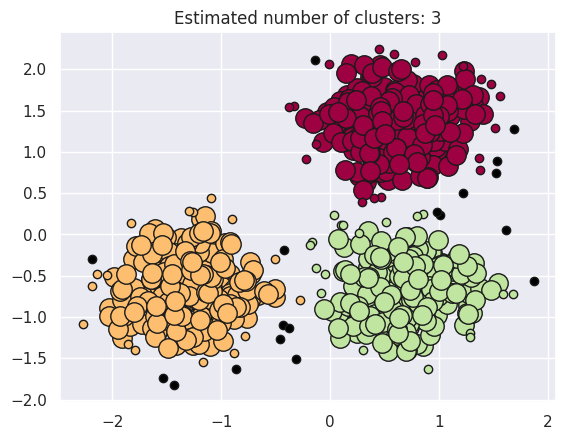

In [ ]:
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()

Interpretasi visual:

* Titik besar berwarna → core samples dalam klaster.

* Titik kecil berwarna → non-core samples, tetap termasuk klaster.

* Titik hitam → noise/outlier.

# Tugas Praktikum
### 1. Tugas K-Means

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


Import Library dan Membaca Dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv('Mall_Customers.csv')

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
# Seleksi fitur

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


Menentukan Jumlah K dengan Elbow Method

k = 2, Inertia = 181363.60
k = 3, Inertia = 106348.37
k = 4, Inertia = 73679.79
k = 5, Inertia = 44448.46
k = 6, Inertia = 37233.81
k = 7, Inertia = 30241.34
k = 8, Inertia = 25036.42
k = 9, Inertia = 21916.79
k = 10, Inertia = 20072.07


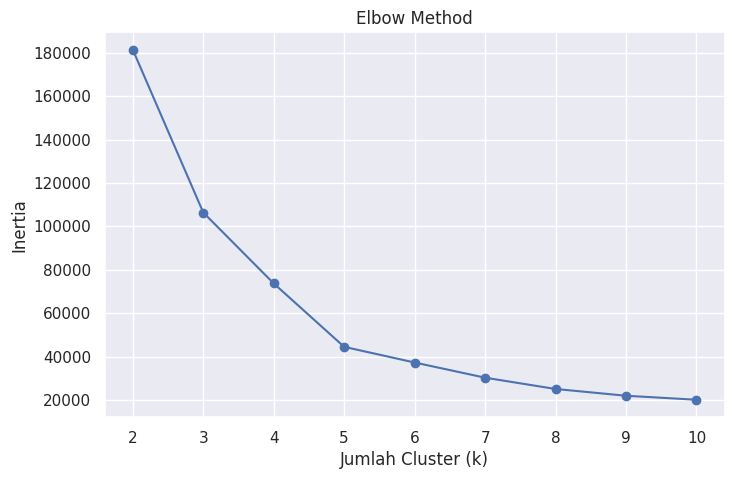

In [ ]:
# Menentukan jumlah cluster dengan Elbow Method

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

for k, nilai in zip(range(2, 11), inertia):
    print(f"k = {k}, Inertia = {nilai:.2f}")

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(range(2, 11))
plt.show()

Validasi dengan Silhouette Score

k = 2, Silhouette Score = 0.2969
k = 3, Silhouette Score = 0.4676
k = 4, Silhouette Score = 0.4932
k = 5, Silhouette Score = 0.5539
k = 6, Silhouette Score = 0.5398
k = 7, Silhouette Score = 0.5288
k = 8, Silhouette Score = 0.4548
k = 9, Silhouette Score = 0.4561
k = 10, Silhouette Score = 0.4411


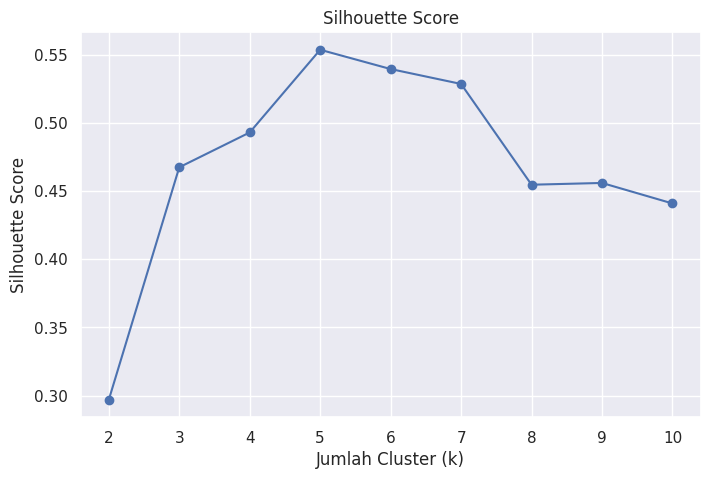

In [ ]:
# Menghitung Silhouette Score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

for k, score in zip(range(2, 11), silhouette_scores):
    print(f"k = {k}, Silhouette Score = {score:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')
plt.xticks(range(2, 11))
plt.show()

Membuat Model K-Means

In [ ]:
# Model K-Means dengan k = 5

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


Visualisasi Hasil Clustering

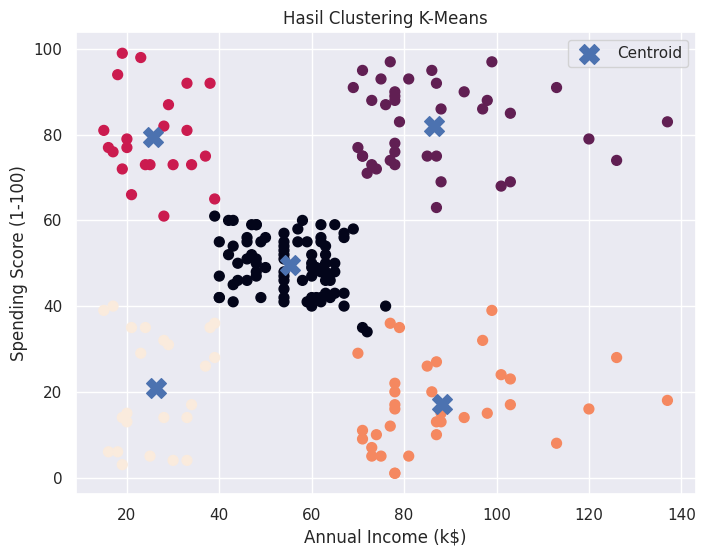

In [ ]:
# Visualisasi hasil clustering

plt.figure(figsize=(8, 6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    s=50
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker='X',
    s=200,
    label='Centroid'
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Hasil Clustering K-Means')
plt.legend()
plt.show()

Visualisasi menunjukkan hasil pengelompokan pelanggan berdasarkan Annual Income (k$) dan Spending Score (1-100). Setiap kelompok ditampilkan dengan warna yang berbeda, sedangkan tanda X menunjukkan posisi centroid dari masing-masing cluster.

Melihat Jumlah Anggota Setiap Cluster

In [ ]:
print("Jumlah pelanggan pada setiap cluster:")
for cluster, jumlah in cluster_counts.items():
    print(f"Cluster {cluster}: {jumlah} pelanggan")

print(f"\nTotal pelanggan: {cluster_counts.sum()}")

Jumlah pelanggan pada setiap cluster:
Cluster 0: 81 pelanggan
Cluster 1: 39 pelanggan
Cluster 2: 22 pelanggan
Cluster 3: 35 pelanggan
Cluster 4: 23 pelanggan

Total pelanggan: 200


### Kesimpulan K-Means

Clustering dilakukan menggunakan fitur `Annual Income (k$)` dan `Spending Score (1-100)`. Berdasarkan Elbow Method dan Silhouette Score, jumlah cluster yang digunakan adalah **5**, dengan Silhouette Score sebesar **0.5539**.

Hasil K-Means membagi 200 pelanggan ke dalam 5 cluster, yaitu Cluster 0 sebanyak 81 pelanggan, Cluster 1 sebanyak 39 pelanggan, Cluster 2 sebanyak 22 pelanggan, Cluster 3 sebanyak 35 pelanggan, dan Cluster 4 sebanyak 23 pelanggan.

### 2. Tugas DBSCAN
Membuat Dataset make_moons dan Normalisasi

In [2]:
import numpy as np

from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

# Membuat dataset make_moons
X, y = make_moons(
    n_samples=1000,
    noise=0.05,
    random_state=42
)

# Normalisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Jumlah sampel :", X_scaled.shape[0])
print("Jumlah fitur  :", X_scaled.shape[1])

Jumlah sampel : 1000
Jumlah fitur  : 2


In [3]:
# Menjalankan DBSCAN

dbscan = DBSCAN(
    eps=0.2,
    min_samples=5
)

labels = dbscan.fit_predict(X_scaled)

print("DBSCAN berhasil dijalankan.")

DBSCAN berhasil dijalankan.


In [4]:
# Menghitung jumlah cluster dan noise

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print("Parameter DBSCAN")
print("eps         :", 0.2)
print("min_samples :", 5)
print()
print("Jumlah Cluster :", n_clusters)
print("Jumlah Noise   :", n_noise)

Parameter DBSCAN
eps         : 0.2
min_samples : 5

Jumlah Cluster : 2
Jumlah Noise   : 0


Evaluasi DBSCAN

In [5]:
from sklearn.metrics import (
    homogeneity_score,
    completeness_score,
    v_measure_score,
    adjusted_rand_score,
    adjusted_mutual_info_score,
    silhouette_score
)

# Menghitung metrik evaluasi
homogeneity = homogeneity_score(y, labels)
completeness = completeness_score(y, labels)
v_measure = v_measure_score(y, labels)
ari = adjusted_rand_score(y, labels)
ami = adjusted_mutual_info_score(y, labels)
silhouette = silhouette_score(X_scaled, labels)

print("Hasil Evaluasi DBSCAN")
print("---------------------")
print(f"Homogeneity : {homogeneity:.4f}")
print(f"Completeness: {completeness:.4f}")
print(f"V-measure   : {v_measure:.4f}")
print(f"ARI         : {ari:.4f}")
print(f"AMI         : {ami:.4f}")
print(f"Silhouette  : {silhouette:.4f}")

Hasil Evaluasi DBSCAN
---------------------
Homogeneity : 1.0000
Completeness: 1.0000
V-measure   : 1.0000
ARI         : 1.0000
AMI         : 1.0000
Silhouette  : 0.3912


Visualisasi Hasil DBSCAN

In [6]:
# Menentukan core sample

core_samples = np.zeros_like(labels, dtype=bool)
core_samples[dbscan.core_sample_indices_] = True

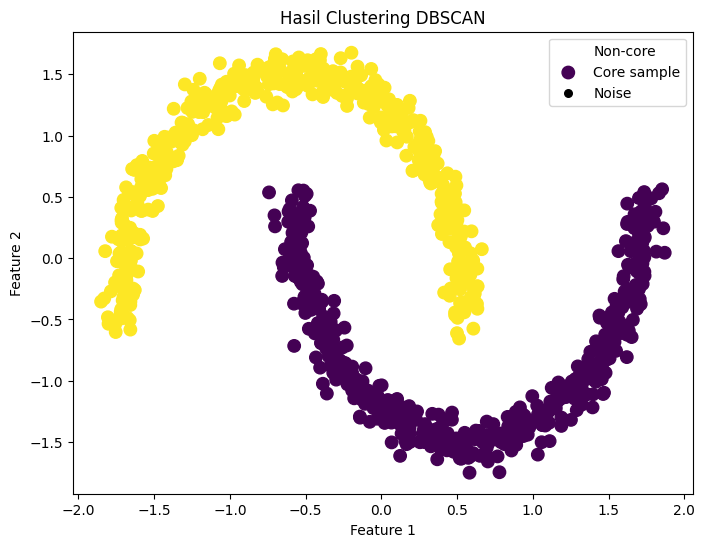

In [8]:
import matplotlib.pyplot as plt

# Menentukan core sample
core_samples = np.zeros_like(labels, dtype=bool)
core_samples[dbscan.core_sample_indices_] = True

plt.figure(figsize=(8, 6))

# Non-core sample
non_core = (~core_samples) & (labels != -1)

plt.scatter(
    X_scaled[non_core, 0],
    X_scaled[non_core, 1],
    c=labels[non_core],
    s=20,
    label='Non-core'
)

# Core sample
plt.scatter(
    X_scaled[core_samples, 0],
    X_scaled[core_samples, 1],
    c=labels[core_samples],
    s=80,
    label='Core sample'
)

# Noise
noise = labels == -1

plt.scatter(
    X_scaled[noise, 0],
    X_scaled[noise, 1],
    c='black',
    s=30,
    label='Noise'
)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Hasil Clustering DBSCAN')
plt.legend()
plt.show()

Eksperimen DBSCAN

In [9]:
# Eksperimen variasi eps dan min_samples

eps_values = [0.05, 0.1, 0.3, 0.5]
min_samples_values = [3, 10, 20]

results = []

for eps in eps_values:
    for min_samples in min_samples_values:

        dbscan_exp = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels_exp = dbscan_exp.fit_predict(X_scaled)

        # Jumlah cluster
        n_clusters = len(set(labels_exp)) - (
            1 if -1 in labels_exp else 0
        )

        # Jumlah noise
        n_noise = list(labels_exp).count(-1)

        # Evaluasi
        homogeneity = homogeneity_score(y, labels_exp)
        completeness = completeness_score(y, labels_exp)
        v_measure = v_measure_score(y, labels_exp)
        ari = adjusted_rand_score(y, labels_exp)
        ami = adjusted_mutual_info_score(y, labels_exp)

        # Silhouette
        mask = labels_exp != -1

        if n_clusters >= 2 and len(set(labels_exp[mask])) >= 2:
            silhouette = silhouette_score(
                X_scaled[mask],
                labels_exp[mask]
            )
        else:
            silhouette = np.nan

        results.append([
            eps,
            min_samples,
            n_clusters,
            n_noise,
            homogeneity,
            completeness,
            v_measure,
            ari,
            ami,
            silhouette
        ])

Menampilkan Hasil Eksperimen

In [11]:
import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=[
        'eps',
        'min_samples',
        'clusters',
        'noise',
        'homogeneity',
        'completeness',
        'v_measure',
        'ARI',
        'AMI',
        'silhouette'
    ]
)

results_df.round(4)

,eps,min_samples,clusters,noise,homogeneity,completeness,v_measure,ARI,AMI,silhouette
0,0.05,3,69,186,0.8156,0.1525,0.2570,0.0300,0.2438,0.3492
1,0.05,10,3,970,0.0307,0.1268,0.0494,0.0023,0.0459,0.8807
2,0.05,20,0,1000,0.0000,1.0000,0.0000,0.0000,0.0000,NaN
3,0.10,3,2,14,0.9862,0.9029,0.9427,0.9722,0.9426,0.3939
4,0.10,10,7,57,0.9433,0.4095,0.5711,0.5234,0.5698,0.2097
5,0.10,20,6,850,0.1539,0.1555,0.1547,0.0168,0.1509,0.7873
6,0.30,3,2,0,1.0000,1.0000,1.0000,1.0000,1.0000,0.3912
7,0.30,10,2,0,1.0000,1.0000,1.0000,1.0000,1.0000,0.3912
8,0.30,20,2,0,1.0000,1.0000,1.0000,1.0000,1.0000,0.3912
9,0.50,3,2,0,1.0000,1.0000,1.0000,1.0000,1.0000,0.3912


### Kesimpulan DBSCAN

Pada eksperimen DBSCAN, perubahan nilai `eps` dan `min_samples` memengaruhi jumlah cluster dan noise yang dihasilkan. Pada `eps=0.05`, jumlah noise relatif tinggi, sedangkan pada `eps=0.30` dan `eps=0.50` seluruh kombinasi menghasilkan 2 cluster tanpa noise.

Hasil evaluasi menunjukkan bahwa kombinasi `eps=0.30` dan `eps=0.50` menghasilkan nilai Homogeneity, Completeness, V-measure, ARI, dan AMI sebesar **1.0000**, dengan Silhouette Score sebesar **0.3912**. Pada `eps=0.05` dengan `min_samples=20`, hanya terbentuk 1 cluster sehingga nilai Silhouette tidak dapat dihitung dan menghasilkan `NaN`.